In [8]:
import numpy as np
import matplotlib.pyplot as plt
from control import *
import sys
sys.path.append('../..')
from simulation.model.motor_params import *

In [9]:
# Transfer function (copied from dc_motor_tf.ipynb)

num = [Kt]
den = [J*L, J*R + B*L, B*R + Ke*Kt]
motor_tf = tf(num, den)
print(motor_tf)

<TransferFunction>: sys[8]
Inputs (1): ['u[0]']
Outputs (1): ['y[0]']

             0.1
  --------------------------
  5e-06 s^2 + 0.02 s + 0.012


In [10]:
# PID controller transfer function
# G_pid(s) = Kp + Ki/s + Kd*s = (Kd*s^2 + Kp*s + Ki) / s

Kp = 10.0
Ki = 5.0
Kd = 0.1

pid_tf = tf([Kd, Kp, Ki], [1, 0])
print(pid_tf)

<TransferFunction>: sys[9]
Inputs (1): ['u[0]']
Outputs (1): ['y[0]']

  0.1 s^2 + 10 s + 5
  ------------------
          s


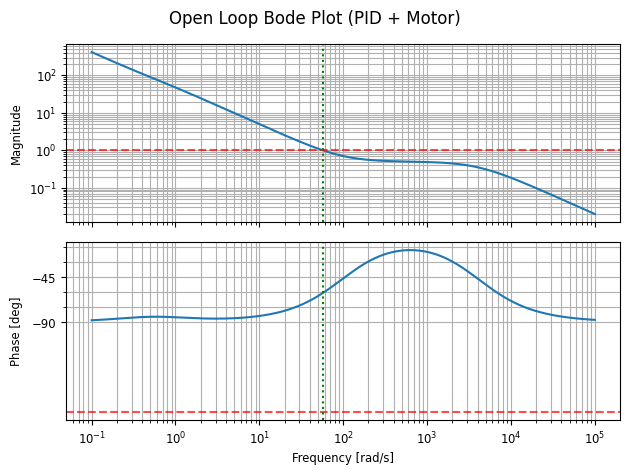

In [11]:
# Bode plot of open loop (PID + Motor)

response_ol = frequency_response(open_loop)
response_ol.plot()

fig = plt.gcf()
axes = fig.get_axes()
ax_mag = axes[0]
ax_phase = axes[1]

ax_mag.axhline(1, color='red', linestyle='--', alpha=0.7, label='0 dB')
ax_mag.axvline(wp, color='green', linestyle=':', label=f'Crossover {wp:.1f} rad/s')
ax_phase.axhline(-180, color='red', linestyle='--', alpha=0.7)
ax_phase.axvline(wp, color='green', linestyle=':')

plt.suptitle('Open Loop Bode Plot (PID + Motor)')
plt.show()

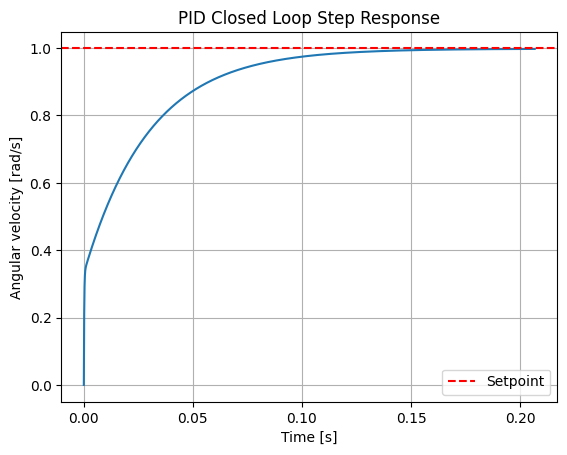

In [12]:
# Closed loop system
# R(s) --> [PID] --> [Motor] --> Y(s)
#                 <-------------|

open_loop = pid_tf * motor_tf
closed_loop = feedback(open_loop, 1)

t, y = step_response(closed_loop)

plt.plot(t, y)
plt.axhline(y=1.0, color='r', linestyle='--', label='Setpoint')
plt.xlabel('Time [s]')
plt.ylabel('Angular velocity [rad/s]')
plt.title('PID Closed Loop Step Response')
plt.legend()
plt.grid(True)
plt.show()

In [13]:
# Stability margins

gm, pm, wg, wp = margin(open_loop)
print(f'Gain margin: {20*np.log10(gm):.1f} dB')
print(f'Phase margin: {pm:.1f} deg')
print(f'Gain crossover frequency: {wp:.2f} rad/s')
print(f'Phase crossover frequency: {wg:.2f} rad/s')

Gain margin: inf dB
Phase margin: 119.3 deg
Gain crossover frequency: 57.45 rad/s
Phase crossover frequency: nan rad/s


In [14]:
print(f'We can increase Kp by factor: {pm/60:.1f}x before reaching 60 deg phase margin')

We can increase Kp by factor: 2.0x before reaching 60 deg phase margin
